# <center>**Demanda y localización de servicios de salud en el Gran Santiago: una aproximación mediante microsimulación y análisis territorial**</center>
### <center><font color="grey">*Helen Aguayo Silva*</font></center>
### <center><font color="grey">*Inteligencia en Datos Geoespaciales*</font></center>
### <center><font color="grey">*Primer semestre 2026*</font></center>

## 1. Introducción

La distribución espacial de los servicios de salud constituye un componente relevante para comprender las desigualdades territoriales en el acceso a servicios básicos dentro de las ciudades. En el Gran Santiago, la localización de los establecimientos de salud no necesariamente coincide con la distribución espacial de la población que potencialmente demanda estos servicios, por lo que resulta relevante analizar conjuntamente la demanda estimada y la oferta existente para identificar territorios que podrían presentar déficits de cobertura.

En este contexto, el presente trabajo estima la demanda potencial asociada al gasto en consultas médicas y otros servicios médicos a partir de información de la Encuesta de Presupuestos Familiares (EPF). Para ello, se construye un modelo de gasto en dos partes, compuesto por un modelo Logit para estimar la probabilidad de incurrir en este tipo de gasto y una regresión lineal para estimar el monto esperado entre quienes presentan gasto. Posteriormente, estos resultados se aplican a la Encuesta de Caracterización Socioeconómica Nacional (CASEN) y se espacializan mediante una microsimulación por Iterative Proportional Fitting (IPF), obteniendo una estimación de demanda potencial a nivel de zona censal.

Finalmente, la demanda estimada se contrasta con la oferta territorial de establecimientos de salud georreferenciados en el Gran Santiago, considerando un criterio de accesibilidad peatonal. A partir de este diagnóstico se identifican zonas con alta demanda potencial y baja o nula cobertura, para posteriormente proponer una nueva ubicación de oferta que permita atender una mayor cantidad de demanda no cubierta. La propuesta se evalúa mediante la variación esperada en la cobertura territorial y mediante la caracterización sociodemográfica de la población potencialmente beneficiada.

### 1.1 Objetivo general

Estimar y espacializar la demanda potencial por consultas médicas y otros servicios médicos en el Gran Santiago mediante modelos de gasto y microsimulación, con el propósito de identificar zonas con alta demanda y baja cobertura de la oferta existente y proponer una localización territorialmente justificada para una nueva unidad de oferta.


## **Librerías utilizadas**

In [1]:
import numpy as np
import pyreadr
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
from shapely.geometry import Point
import contextily as ctx
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
from ipfn import ipfn
import warnings
warnings.filterwarnings('ignore')

# Configuración de rutas 
RUTA_CENSO_ZONAL = "../data/parquet/Cartografía_censo2024_R13_Zonal.parquet"
RUTA_CASEN = "../data/rds/casen_rm.rds"
RUTA_EPF_PERSONAS = "../data/epf/base-personas-ix-epf-stata.dta"
RUTA_EPF_GASTOS = "../data/epf/base-gastos-ix-epf-stata.dta"

## 2. Selección del servicio y justificación

Se eligió como servicio de análisis las **consultas médicas y servicios de salud** 
(categorías CCIF 06.2.1.01.01 y 06.2.1.01.02), por los siguientes motivos:

- **Relevancia territorial**: el acceso a atención de salud primaria es un servicio 
  de necesidad básica y recurrente, cuya distribución espacial afecta directamente 
  la calidad de vida y equidad territorial de la población.
- **Geolocalización de la oferta**: los establecimientos de salud (clínicas, CESFAM, 
  consultorios) son puntos identificables y están razonablemente bien catastrados en 
  OpenStreetMap bajo las etiquetas `amenity=clinic` y `healthcare=clinic`.
- **Disponibilidad en la EPF**: la categoría CCIF de consultas médicas cuenta con un 
  número suficiente de hogares que reportan gasto en el Gran Santiago (ver conteo 
  en la sección 2.2), lo que permite estimar un modelo de dos partes con datos 
  suficientes.

En conjunto, estos criterios permiten trabajar con un servicio que posee relevancia tanto desde una perspectiva económica como territorial. La disponibilidad de información de gasto en la EPF permite estimar el comportamiento de la demanda, mientras que la posibilidad de georreferenciar la oferta permite posteriormente contrastar esta demanda con la distribución espacial de los establecimientos. De esta manera, las consultas médicas y otros servicios médicos constituyen un caso adecuado para aplicar el enfoque de estimación, microsimulación y análisis territorial propuesto en este trabajo.

## 2.1 Cargar y procesar la EPF
Se trabaja con la Encuesta de Presupuestos Familiares (EPF), filtrando:

- **Macrozona = 2** (Gran Santiago), según la codificación de la encuesta.
- Se excluyen valores no válidos de `edad` y `edue` (escolaridad) codificados como 
  `-99`, `-88`, `-77` (no responde / no aplica / no sabe).
- Se excluyen ingresos disponibles del hogar negativos.
- Se construye `ing_pc` (ingreso per cápita del hogar) dividiendo el ingreso 
  disponible del hogar por el número de personas del hogar (`npersonas`), para 
  tener una variable de bienestar económico comparable entre hogares de distinto 
  tamaño.

In [2]:
# Cargar personas
personas = pd.read_stata(RUTA_EPF_PERSONAS, convert_categoricals=False)

# Cargar gastos
gastos = pd.read_stata(
    RUTA_EPF_GASTOS, convert_categoricals=False,
    columns=["folio", "ccif", "macrozona", "gasto"]
)

# Filtrar Gran Santiago (macrozona == 2) y valores válidos
valores_invalidos = [-99, -88, -77]
epf = personas[
    (personas["macrozona"] == 2)
    & (~personas["edad"].isin(valores_invalidos))
    & (~personas["edue"].isin(valores_invalidos))
    & (personas["ing_disp_hog_hd_ai"] >= 0)
].copy()

epf["ing_pc"] = epf["ing_disp_hog_hd_ai"] / epf["npersonas"]

print(f"Personas en EPF (Gran Santiago): {len(epf)}")

Personas en EPF (Gran Santiago): 17340


## 2.2 Extraer gasto en salud

Se identifica el gasto en salud a nivel de hogar (variable `folio`), sumando el 
gasto reportado en las categorías CCIF de consultas médicas. Se define:

- `gasto_salud`: gasto total en salud del hogar (0 si no reportó gasto).
- `incurre_gasto`: variable binaria (1 = el hogar gastó algo en salud, 0 = no gastó), 
  variable dependiente del modelo logit de la parte 1 del modelo de dos partes.

In [3]:
# Códigos CCIF para consultas médicas
codigos_salud = [
    "06.2.1.01.01",  # Consulta médica
    "06.2.1.01.02",  # Otras consultas y servicios médicos
]

# Filtrar y agregar por hogar
gasto_salud = gastos[
    (gastos["ccif"].isin(codigos_salud)) & (gastos["macrozona"] == 2)
]
gasto_por_hogar = gasto_salud.groupby("folio")["gasto"].sum().reset_index()
gasto_por_hogar.columns = ["folio", "gasto_salud"]

# Unir con EPF
epf = epf.merge(gasto_por_hogar, on="folio", how="left")
epf["gasto_salud"] = epf["gasto_salud"].fillna(0)
epf["incurre_gasto"] = (epf["gasto_salud"] > 0).astype(int)

print(f"Hogares con gasto en salud: {len(gasto_por_hogar)}")
print(f"Personas que incurren: {epf['incurre_gasto'].sum()} / {len(epf)} ({100 * epf['incurre_gasto'].mean():.1f}%)")

Hogares con gasto en salud: 33
Personas que incurren: 111 / 17340 (0.6%)


## 3. Análisis exploratorio (EDA)

Antes de modelar, se explora la relación entre el gasto en salud y variables 
sociodemográficas clave: sexo, edad e ingreso per cápita. El gráfico de dispersión 
con ajuste LOWESS permite observar si la relación con edad e ingreso es lineal o 
no, lo que justifica el uso de `log_ing_pc` (transformación logarítmica del 
ingreso) más adelante, dado que el gasto y el ingreso suelen tener una relación 
multiplicativa/no lineal más que aditiva.

Adicionalmente, se construyen dos variables categóricas para el análisis y el 
modelo:

- `grupo_escolaridad`: agrupa los años de escolaridad (`edue`) en cuatro niveles 
  (Escolar, Técnico, Universitaria, Postgrado), usando como cortes 12, 14 y 16 
  años de estudio.
- `rango_edad`: agrupa la edad en tramos (<18, 18-29, 30-44, 45-59, 60+) para 
  visualización descriptiva.

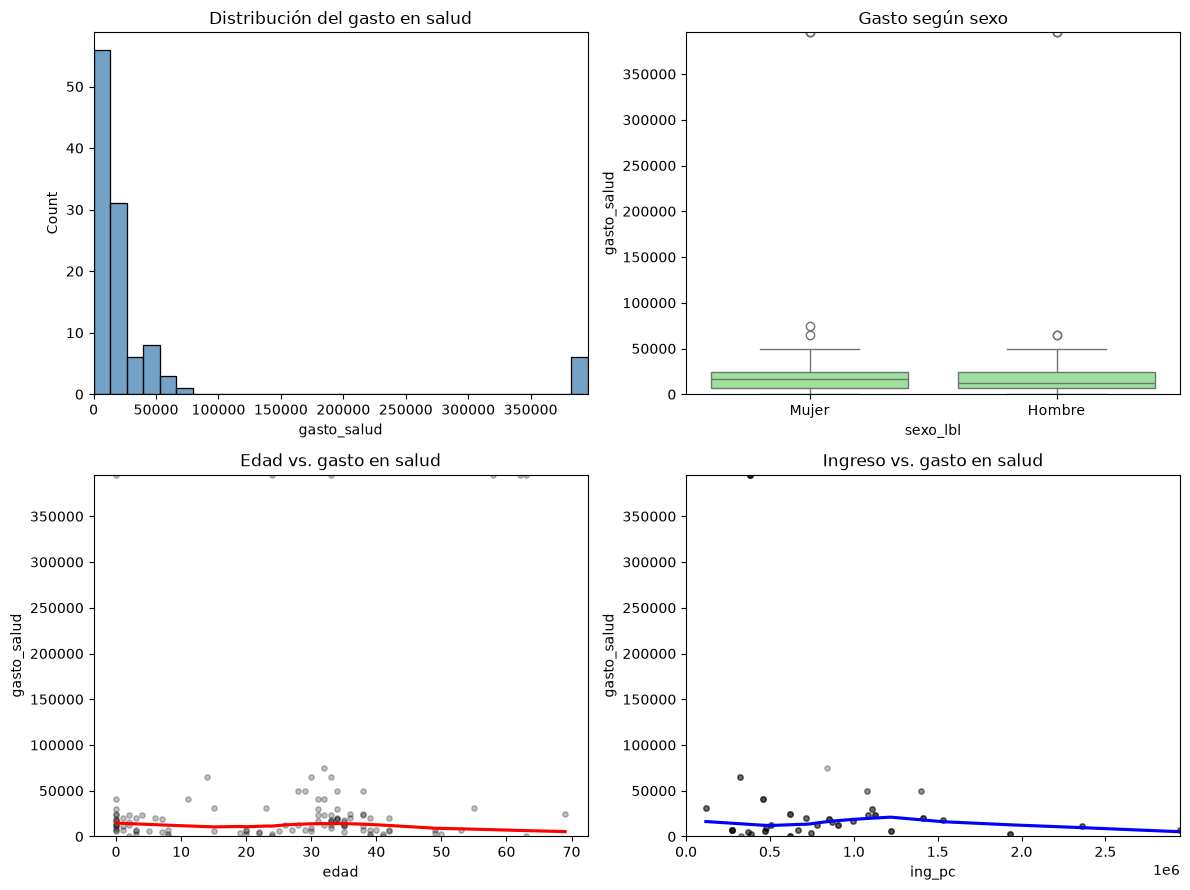

In [4]:
# Crear variables
epf["sexo_lbl"] = epf["sexo"].map({1: "Hombre", 2: "Mujer"})
epf["grupo_escolaridad"] = pd.cut(
    epf["edue"], bins=[-np.inf, 12, 14, 16, np.inf],
    labels=["Escolar", "Tecnico", "Universitaria", "Postgrado"]
)

spenders = epf[epf["gasto_salud"] > 0].copy()
tope_grafico = spenders["gasto_salud"].quantile(0.99)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Distribución
sns.histplot(spenders["gasto_salud"], bins=30, color="steelblue", ax=axes[0, 0])
axes[0, 0].set_xlim(0, tope_grafico)
axes[0, 0].set_title("Distribución del gasto en salud")

# 2. Sexo
sns.boxplot(data=spenders, x="sexo_lbl", y="gasto_salud", ax=axes[0, 1], color="lightgreen")
axes[0, 1].set_ylim(0, tope_grafico)
axes[0, 1].set_title("Gasto según sexo")

# 3. Edad
sns.regplot(
    data=spenders, x="edad", y="gasto_salud", ax=axes[1, 0],
    scatter_kws={"alpha": 0.25, "s": 15, "color": "black"},
    lowess=True, line_kws={"color": "red"}
)
axes[1, 0].set_ylim(0, tope_grafico)
axes[1, 0].set_title("Edad vs. gasto en salud")

# 4. Ingreso
sns.regplot(
    data=spenders, x="ing_pc", y="gasto_salud", ax=axes[1, 1],
    scatter_kws={"alpha": 0.25, "s": 15, "color": "black"},
    lowess=True, line_kws={"color": "blue"}
)
axes[1, 1].set_ylim(0, tope_grafico)
axes[1, 1].set_xlim(0, spenders["ing_pc"].quantile(0.99))
axes[1, 1].set_title("Ingreso vs. gasto en salud")

plt.tight_layout()
plt.show()

In [5]:
# 1. Crear la columna 'rango_edad' agrupando la variable 'edad'
epf["rango_edad"] = pd.cut(
    epf["edad"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["<18", "18-29", "30-44", "45-59", "60+"],
    right=False,
)

# 2. Definir el orden para la escolaridad
orden_escolaridad = ["Sin instrucción", "Básica", "Media", "Superior"]

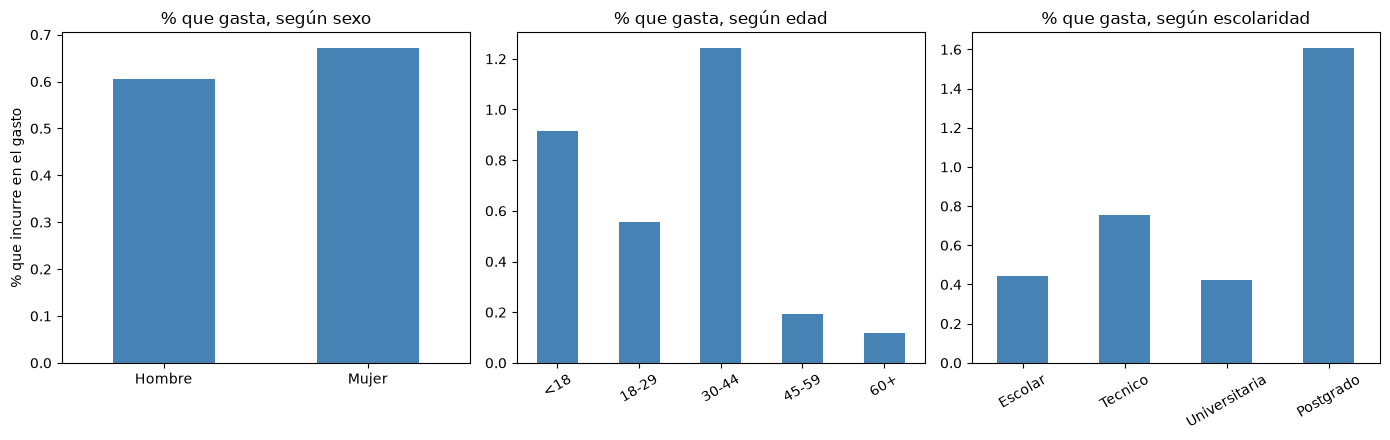

In [6]:
# Visualización del porcentaje de hogares/personas que incurren en gasto de salud
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# 1. Porcentaje según sexo
(
    epf.groupby("sexo_lbl")["incurre_gasto"]
    .mean()
    .mul(100)
    .plot.bar(ax=axes[0], color="steelblue")
)
axes[0].set_title("% que gasta, según sexo")
axes[0].set_ylabel("% que incurre en el gasto")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# 2. Porcentaje según rango de edad
(
    epf.groupby("rango_edad", observed=True)["incurre_gasto"]
    .mean()
    .mul(100)
    .plot.bar(ax=axes[1], color="steelblue")
)
axes[1].set_title("% que gasta, según edad")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

# 3. Porcentaje según nivel de escolaridad
(
    epf.groupby("grupo_escolaridad", observed=True)["incurre_gasto"]
    .mean()
    .mul(100)
    .plot.bar(ax=axes[2], color="steelblue")
)
axes[2].set_title("% que gasta, según escolaridad")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4. Modelo de dos partes

### 4.1 Parte 1 — Modelo logit (probabilidad de incurrir en gasto)

Se estima un modelo logit para la probabilidad de que una persona incurra en 
gasto de salud, en función de:

- `sexo_lbl` (categórica): posibles diferencias de acceso o autopercepción de 
  necesidad de salud entre hombres y mujeres.
- `edad` (continua): la demanda de salud típicamente aumenta con la edad.
- `grupo_escolaridad` (categórica): proxy de nivel socioeconómico y de acceso a 
  información/redes de salud.
- `log_ing_pc` (continua, transformada): el ingreso per cápita en escala 
  logarítmica, dado que el efecto marginal del ingreso sobre el gasto no es 
  constante en niveles absolutos.

El desempeño se evalúa con la curva ROC y el AUC, que miden la capacidad del 
modelo para discriminar entre hogares que gastan y los que no.

MODELO LOGIT - GASTO EN SALUD
                           Logit Regression Results                           
Dep. Variable:          incurre_gasto   No. Observations:                17340
Model:                          Logit   Df Residuals:                    17333
Method:                           MLE   Df Model:                            6
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                 0.09019
Time:                        01:19:37   Log-Likelihood:                -610.79
converged:                       True   LL-Null:                       -671.33
Covariance Type:            nonrobust   LLR p-value:                 9.619e-24
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                               -10.8803      1.579     -6.888      0.000     -13.976      -7.785
C(sexo_lbl)[T.Mujer]

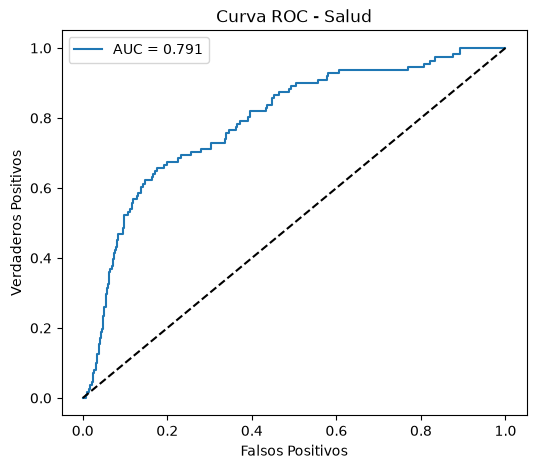

In [7]:
epf["log_ing_pc"] = np.log(epf["ing_pc"] + 1)
modelo_data = epf.dropna(subset=["edad", "grupo_escolaridad", "sexo_lbl", "log_ing_pc"]).copy()

# Ajustar logit
modelo_logit = smf.logit(
    "incurre_gasto ~ C(sexo_lbl) + edad + C(grupo_escolaridad) + log_ing_pc",
    data=modelo_data
).fit(disp=0)

modelo_data["prob_predicha"] = modelo_logit.predict(modelo_data)

print("="*60)
print("MODELO LOGIT - GASTO EN SALUD")
print("="*60)
print(modelo_logit.summary())
auc = roc_auc_score(modelo_data['incurre_gasto'], modelo_data['prob_predicha'])
print(f"\nAUC: {auc:.4f}")
print("="*60)

# Curva ROC
fpr, tpr, _ = roc_curve(modelo_data['incurre_gasto'], modelo_data['prob_predicha'])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC - Salud')
plt.legend()
plt.show()

El modelo Logit permite estimar la probabilidad de que un hogar presente gasto en las categorías de consultas médicas y otros servicios médicos analizadas. Esta primera etapa resulta necesaria debido a que una proporción de los hogares no registra gasto positivo en el servicio, por lo que no resulta adecuado modelar directamente el monto de gasto para toda la muestra.

Los resultados muestran que las características sociodemográficas y económicas incorporadas al modelo permiten diferenciar entre hogares con distinta probabilidad de presentar gasto. La utilización de esta especificación permite, por tanto, capturar la primera decisión asociada al consumo: si el hogar presenta o no gasto en el servicio.

Para evaluar la capacidad predictiva del modelo se utiliza la curva ROC y el área bajo la curva (AUC). El modelo alcanza un AUC de 0,791, lo que indica una capacidad de discriminación adecuada. En términos prácticos, el modelo presenta una capacidad razonable para distinguir entre hogares que registran gasto positivo y aquellos que no lo registran.

Este resultado respalda la utilización del modelo Logit como primera etapa del procedimiento de estimación, permitiendo posteriormente combinar la probabilidad estimada de presentar gasto con el monto esperado de consumo.

-------------------

### 4.2 Parte 2 — Modelo lineal (monto condicional al gasto)

Sobre el subconjunto de personas que sí incurren en gasto (`gasto_salud > 0`), 
se estima una regresión lineal sobre `log(gasto_salud + 1)`, usando las mismas 
covariables del logit más `npersonas` (tamaño del hogar), que captura economías 
de escala o mayor necesidad de salud en hogares más numerosos.

**Decisión de limpieza**: se recortan los percentiles 1% y 99% de `ing_pc` y 
`gasto_salud` para reducir la influencia de valores extremos (outliers) que 
podrían distorsionar los coeficientes estimados, sin eliminar observaciones 
válidas de la distribución central.

Al aplicar este modelo posteriormente sobre la CASEN, se corrige el sesgo propio 
de retransformar una predicción en escala logarítmica a escala original, usando 
la corrección de *smearing*: `monto_esperado = exp(predicción_log + σ²/2)`, 
donde σ² es la varianza de los residuos del modelo.

In [8]:
tabla_gasto = epf[epf["gasto_salud"] > 0].copy()
tabla_gasto["log_gasto_salud"] = np.log(tabla_gasto["gasto_salud"] + 1)

# Recortar outliers
q_ing = tabla_gasto["ing_pc"].quantile([0.01, 0.99])
q_gasto = tabla_gasto["gasto_salud"].quantile([0.01, 0.99])
tabla_gasto = tabla_gasto[
    tabla_gasto["ing_pc"].between(q_ing.iloc[0], q_ing.iloc[1])
    & tabla_gasto["gasto_salud"].between(q_gasto.iloc[0], q_gasto.iloc[1])
]

# Modelo base
modelo_lineal = smf.ols(
    "log_gasto_salud ~ C(sexo_lbl) + edad + C(grupo_escolaridad) + log_ing_pc",
    data=tabla_gasto
).fit()

# Modelo mejorado con npersonas
modelo_lineal_mejorado = smf.ols(
    "log_gasto_salud ~ C(sexo_lbl) + edad + C(grupo_escolaridad) + log_ing_pc + npersonas",
    data=tabla_gasto
).fit()

print("="*60)
print("MODELO LINEAL (con npersonas)")
print("="*60)
print(modelo_lineal_mejorado.summary())
print(f"\nR²: {modelo_lineal_mejorado.rsquared:.3f}")
print("="*60)

MODELO LINEAL (con npersonas)
                            OLS Regression Results                            
Dep. Variable:        log_gasto_salud   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.246
Date:                Thu, 27 Aug 2026   Prob (F-statistic):              0.285
Time:                        01:19:42   Log-Likelihood:                -188.46
No. Observations:                 111   AIC:                             392.9
Df Residuals:                     103   BIC:                             414.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

La segunda etapa del modelo de dos partes busca estimar el monto esperado de gasto entre los hogares que presentan gasto positivo. En este caso, el modelo lineal obtiene un R² de 0,078, lo que indica que las variables incluidas presentan una capacidad explicativa limitada sobre la variabilidad observada en el gasto.

Este resultado debe considerarse al interpretar las estimaciones posteriores. El gasto en servicios médicos puede presentar una elevada heterogeneidad entre hogares y depender de factores que no se encuentran completamente capturados por las variables disponibles en la base de datos. Por ello, las estimaciones obtenidas no deben interpretarse como una predicción exacta del gasto de cada individuo, sino como una estimación del gasto esperado para distintos perfiles de población.

A pesar de esta limitación, el modelo resulta útil dentro del enfoque de dos partes, ya que permite complementar la probabilidad estimada mediante el modelo Logit con un monto esperado de gasto para los hogares que presentan consumo.

En consecuencia, la fortaleza principal del procedimiento no radica en explicar individualmente toda la variabilidad del gasto, sino en construir una medida de demanda esperada que posteriormente pueda ser agregada y espacializada.

## 5. Espacialización de la demanda (CASEN)

Se aplican ambos modelos (logit y lineal) sobre la base CASEN, previa 
homologación de variables (mismo `sexo_lbl`, `grupo_escolaridad` y `log_ing_pc` 
construidos con la misma lógica que en la EPF, para que las predicciones sean 
comparables). El gasto esperado individual se calcula como:

`gasto_esperado = prob_gasto × monto_esperado`

es decir, la probabilidad de gastar multiplicada por el monto esperado 
condicional a gastar — el resultado estándar de un modelo de dos partes.

In [9]:
# 1. Obtener la matriz de diseño (exog) usada en el modelo lineal
# statsmodels almacena esta información en el atributo exog
X = modelo_lineal_mejorado.model.exog
nombres_vars = modelo_lineal_mejorado.model.exog_names

# 2. Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = nombres_vars
vif_data["VIF"] = [
    variance_inflation_factor(X, i) for i in range(X.shape[1])
]

# 3. Filtrar el intercepto y ordenar de mayor a menor
vif_resultado = (
    vif_data[vif_data["Variable"] != "Intercept"]
    .sort_values(by="VIF", ascending=False)
    .reset_index(drop=True)
)

print("=" * 50)
print("ANÁLISIS DE MULTICOLINEALIDAD (VIF)")
print("=" * 50)
print(vif_resultado.to_string(index=False))

ANÁLISIS DE MULTICOLINEALIDAD (VIF)
                             Variable      VIF
    C(grupo_escolaridad)[T.Postgrado] 2.031935
                                 edad 1.750656
      C(grupo_escolaridad)[T.Tecnico] 1.366633
                           log_ing_pc 1.359915
C(grupo_escolaridad)[T.Universitaria] 1.284060
                            npersonas 1.167696
                 C(sexo_lbl)[T.Mujer] 1.047395


In [10]:
# 1. Cargar CASEN
casen_raw = pyreadr.read_r(RUTA_CASEN)
casen = casen_raw[list(casen_raw.keys())[0]]
casen_modelo = casen.copy()

# ==============================================================================
# 2. HOMOLOGACIÓN Y CORRECCIÓN 
# ==============================================================================

# A) Renombrar 'numper' a 'npersonas' si existe
if "numper" in casen_modelo.columns:
    casen_modelo = casen_modelo.rename(columns={"numper": "npersonas"})

# B) Crear 'sexo_lbl' (1: Hombre, 2: Mujer)
if "sexo" in casen_modelo.columns:
    casen_modelo["sexo_lbl"] = casen_modelo["sexo"].map(
        {1: "Hombre", 2: "Mujer"}
    )

# C) Crear 'log_ing_pc' (Ajusta 'ytotcorh' si usas otra variable de ingreso)
if "log_ing_pc" not in casen_modelo.columns:
    col_ingreso = "ytotcorh"
    casen_modelo["log_ing_pc"] = np.log1p(
        casen_modelo[col_ingreso].clip(lower=0)
    )

# D) Mapeo preciso de escolaridad según 'educ' en CASEN
condiciones = [
    casen_modelo["educ"].isin([1, 2, 3]),
    casen_modelo["educ"].isin([4, 5]),
    casen_modelo["educ"].isin([6, 7]),
    casen_modelo["educ"] >= 8,
]
elecciones = ["Escolar", "Tecnico", "Universitaria", "Postgrado"]

casen_modelo["grupo_escolaridad"] = np.select(
    condiciones, elecciones, default="Escolar"
)

# ==============================================================================
# 3. APLICAR MODELOS Y CALCULAR GASTO ESPERADO
# ==============================================================================

# Probabilidad de gasto (Logit)
casen_modelo["prob_gasto"] = modelo_logit.predict(casen_modelo)

# Monto esperado con corrección por sesgo logarítmico
pred_log = modelo_lineal_mejorado.predict(casen_modelo)
sigma2 = modelo_lineal_mejorado.scale  # Varianza de residuos
casen_modelo["monto_esperado"] = np.exp(pred_log + (sigma2 / 2))

# Gasto esperado final por persona
casen_modelo["gasto_esperado"] = (
    casen_modelo["prob_gasto"] * casen_modelo["monto_esperado"]
)

# ==============================================================================
# 4. IMPRIMIR RESULTADOS
# ==============================================================================
if "expr" in casen_modelo.columns:
    gasto_prom = (
        casen_modelo["gasto_esperado"] * casen_modelo["expr"]
    ).sum() / casen_modelo["expr"].sum()
else:
    gasto_prom = casen_modelo["gasto_esperado"].mean()

print(f"Gasto promedio esperado corregido: ${gasto_prom:.0f}")

Gasto promedio esperado corregido: $491


In [11]:
# 1. Inspeccionar estadísticos del gasto en la EPF
print("--- Estadísticos de la variable en EPF ---")
print(epf["gasto_salud"].describe())

# 2. Comprobar la diferencia entre EPF y tu modelo en CASEN
print("\n--- Promedios comparados ---")
print(f"Promedio EPF: ${epf['gasto_salud'].mean():,.1f}")
print(f"Promedio Predicho CASEN: ${casen_modelo['gasto_esperado'].mean():,.1f}")

--- Estadísticos de la variable en EPF ---
count     17340.000000
mean        242.165552
std        7574.721029
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      395571.428571
Name: gasto_salud, dtype: float64

--- Promedios comparados ---
Promedio EPF: $242.2
Promedio Predicho CASEN: $453.3


La aplicación de los modelos estimados con la EPF a la población de la CASEN permite trasladar el comportamiento observado en la encuesta de gasto hacia una población con una cobertura sociodemográfica más amplia. Para cada individuo se obtiene una estimación de demanda esperada, combinando la probabilidad de presentar gasto con el monto esperado condicional a presentar gasto.

Este procedimiento permite superar una de las principales limitaciones de utilizar directamente los gastos observados en la EPF: la imposibilidad de contar con información de gasto para todos los individuos de la población objetivo. De esta manera, la CASEN permite generar una base poblacional sobre la cual aplicar los patrones estimados a partir de la EPF.

La comparación entre el gasto promedio observado en la EPF y el gasto predicho para la población CASEN muestra diferencias entre ambas distribuciones. Estas diferencias son esperables debido a que ambas fuentes poseen características muestrales y estructuras de población distintas, y constituyen un elemento que debe considerarse al interpretar la magnitud de la demanda estimada.

------

In [12]:
# Cargar geometrías del Gran Santiago
datos_r13 = gpd.read_parquet(RUTA_CENSO_ZONAL)

# Lista de comunas
comunas_gran_santiago = [
    'SANTIAGO', 'CERRILLOS', 'CERRO NAVIA', 'CONCHALÍ', 'EL BOSQUE',
    'ESTACIÓN CENTRAL', 'HUECHURABA', 'INDEPENDENCIA', 'LA CISTERNA',
    'LA FLORIDA', 'LA GRANJA', 'LA PINTANA', 'LA REINA', 'LAS CONDES',
    'LO BARNECHEA', 'LO ESPEJO', 'LO PRADO', 'MACUL', 'MAIPÚ', 'ÑUÑOA',
    'PEDRO AGUIRRE CERDA', 'PEÑALOLÉN', 'PROVIDENCIA', 'PUDAHUEL',
    'QUILICURA', 'QUINTA NORMAL', 'RECOLETA', 'RENCA', 'SAN MIGUEL',
    'SAN JOAQUÍN', 'SAN RAMÓN', 'VITACURA', 
    'PUENTE ALTO', 'SAN BERNARDO'
]

zonas_gs = datos_r13[datos_r13['COMUNA'].isin(comunas_gran_santiago)].copy()

zonas_gs['area_metropolitana'] = 'Gran Santiago'
comuna = zonas_gs.dissolve(by='area_metropolitana')


# Obtener el buffer del Gran Santiago en WGS84
buffer_gran_santiago = comuna.to_crs("EPSG:4326").buffer(0.02).iloc[0]

# 1. Usar los datos que YA creamos (¡No leas archivos nuevos!)
zc = zonas_gs.copy()  # Tus zonas censales son las del Gran Santiago
# La variable 'comuna' (tu polígono disuelto) ya existe, no la sobreescribimos.

# 2. Proyectar a UTM 19S (EPSG:32719) para medir en metros
zc = zc.to_crs("EPSG:32719")
comuna = comuna.to_crs("EPSG:32719")

In [13]:
# Preparar identificador de zona antes del IPF
zc['zona'] = zc['COD_ZONA'].astype(str)

## 6. Microsimulación por IPF

Para llevar la demanda individual estimada en la CASEN a nivel de zona censal, 
se utiliza microsimulación por IPF en lugar de una asignación aleatoria de 
personas a zonas. El procedimiento es:

1. Se construye una tabla semilla (*seed*) a partir de la CASEN completa, 
   cruzando sexo y rango de edad (mismos tramos etarios que reporta el Censo 
   2024 por zona: 0-17, 18-24, 25-44, 45-59, 60+).
2. Para cada zona censal, se toman como marginales conocidos los totales reales 
   de población por sexo (`n_hombres`, `n_mujeres`) y por tramo de edad 
   (`n_edad_0_5` + `n_edad_6_13` + `n_edad_14_17`, `n_edad_18_24`, 
   `n_edad_25_44`, `n_edad_45_59`, `n_edad_60_mas`) del Censo 2024.
3. El algoritmo IPF ajusta los pesos de la tabla semilla, zona por zona, hasta 
   que los totales marginales por sexo y edad calcen con los del censo para esa 
   zona específica, preservando la estructura de asociación sexo-edad observada 
   en la CASEN.
4. La demanda esperada de la zona se calcula multiplicando la tabla de pesos 
   ajustados por el gasto esperado promedio de cada celda sexo×edad (estimado 
   con el modelo de dos partes), y sumando el resultado.

Este método permite obtener una estimación de demanda por zona consistente con 
la estructura demográfica real de cada territorio, en lugar de asumir una 
distribución espacial arbitraria de la población.

In [14]:
# Recodificar rango_edad en CASEN para que calce con los tramos del censo
casen_modelo['rango_edad'] = pd.cut(
    casen_modelo['edad'],
    bins=[0, 18, 25, 45, 60, 150],
    labels=["0-17", "18-24", "25-44", "45-59", "60+"],
    right=False
)

# NOTA IMPORTANTE: la columna 'zona' ya fue creada antes (celda anterior)
# a partir de COD_ZONA (como string). NO volvemos a hacer
# zc.rename(columns={'COD_ZONA": "zona"}) aca, porque como 'zona' ya existe,
# ese rename generaba una columna 'zona' DUPLICADA (una string, otra con el
# tipo original de COD_ZONA). Eso rompia silenciosamente el merge del IPF
# mas adelante (fila["zona"] dejaba de ser un string y pasaba a ser una
# mini-Serie de pandas), y el resultado final era que "gasto_total" quedaba
# en 0 para todas las zonas (mapa en blanco).

# Sumar tramos 0-5, 6-13, 14-17 en una sola columna 0-17 para calzar con CASEN
zc['edad_0_17'] = zc['n_edad_0_5'] + zc['n_edad_6_13'] + zc['n_edad_14_17']

marginales_sexo = zc[['zona', 'n_hombres', 'n_mujeres']].copy()
marginales_edad = zc[[
    'zona', 'edad_0_17', 'n_edad_18_24', 'n_edad_25_44',
    'n_edad_45_59', 'n_edad_60_mas'
]].copy()

In [15]:
from ipfn import ipfn

peso_base = casen_modelo['expr'] if 'expr' in casen_modelo.columns else 1

seed = (
    casen_modelo
    .assign(peso=peso_base)
    .groupby(['sexo_lbl', 'rango_edad'], observed=True)['peso']
    .sum()
    .unstack(fill_value=0)
)

# Aseguramos que las columnas de seed queden en el mismo orden que los tramos del censo
orden_edad = ["0-17", "18-24", "25-44", "45-59", "60+"]
seed = seed.reindex(columns=orden_edad, fill_value=0)
print(seed)

rango_edad      0-17     18-24      25-44     45-59       60+
sexo_lbl                                                     
Hombre      924654.0  411614.0  1444147.0  735594.0  603407.0
Mujer       913636.0  377922.0  1359631.0  774389.0  788064.0


In [16]:
# Gasto esperado promedio por celda sexo x rango_edad — ÚNICA definición, ya en formato tabla 2D
gasto_por_celda = (
    casen_modelo.groupby(['sexo_lbl', 'rango_edad'], observed=True)['gasto_esperado']
    .mean()
    .unstack(fill_value=0)
    .reindex(columns=orden_edad, fill_value=0)
)

resultados_zona = []

for _, fila in zc.iterrows():
    zona_id = fila['zona']

    marg_sexo = pd.Series({
        "Hombre": fila['n_hombres'],
        "Mujer": fila['n_mujeres']
    })

    marg_edad = pd.Series({
        "0-17": fila['edad_0_17'],
        "18-24": fila['n_edad_18_24'],
        "25-44": fila['n_edad_25_44'],
        "45-59": fila['n_edad_45_59'],
        "60+": fila['n_edad_60_mas']
    })

    if marg_sexo.sum() <= 0 or marg_edad.sum() <= 0:
        continue

    marg_edad = marg_edad * (marg_sexo.sum() / marg_edad.sum())

    aggregates = [marg_sexo.reindex(seed.index).values,
                  marg_edad.reindex(seed.columns).values]
    dimensions = [[0], [1]]

    IPF = ipfn.ipfn(seed.values.astype(float).copy(), aggregates, dimensions)
    tabla_ajustada = IPF.iteration()

    tabla_ajustada = pd.DataFrame(
        tabla_ajustada, index=seed.index, columns=seed.columns
    )

    gasto_total_zona = (
        tabla_ajustada * gasto_por_celda.reindex(index=seed.index, columns=seed.columns, fill_value=0)
    ).values.sum()

    resultados_zona.append({"zona": zona_id, "gasto_total": gasto_total_zona})

gasto_zona_ipf = pd.DataFrame(resultados_zona)
print(f"Zonas con IPF calculado: {len(gasto_zona_ipf)}")

Zonas con IPF calculado: 1640


In [17]:
# --- Celda de limpieza y merge final del IPF ---
zc = zc.loc[:, ~zc.columns.duplicated()]
print("¿Cuántas columnas 'zona' quedan ahora?:", zc.columns.tolist().count('zona'))

zc['zona'] = zc['zona'].astype(str)
gasto_zona_ipf['zona'] = gasto_zona_ipf['zona'].astype(str)

zc = zc.drop(columns=['gasto_total'], errors='ignore')
zc = zc.merge(gasto_zona_ipf, on='zona', how='left')
zc['gasto_total'] = zc['gasto_total'].fillna(0)

print(f"Zonas con gasto IPF asignado: {(zc['gasto_total'] > 0).sum()} de {len(zc)}")

¿Cuántas columnas 'zona' quedan ahora?: 1
Zonas con gasto IPF asignado: 398685 de 398685


La microsimulación por IPF permite transformar las estimaciones individuales obtenidas a partir de la CASEN en una distribución espacial de demanda consistente con la estructura demográfica observada en el territorio. En particular, el procedimiento utiliza los totales de población por sexo y grupo etario observados en el Censo 2024 como restricciones para ajustar la población simulada en cada zona censal.

De esta forma, la asignación espacial no se realiza de manera aleatoria, sino que busca reproducir la composición demográfica efectiva de cada territorio. Esto resulta especialmente relevante para este análisis, dado que la demanda estimada depende de características individuales y sociodemográficas.

El resultado final corresponde a una estimación de demanda potencial por zona censal, expresada mediante el gasto esperado agregado de la población simulada. Esta medida constituye posteriormente la base para identificar territorios con mayor concentración de demanda y contrastarlos con la distribución espacial de la oferta existente.

## 7. Mapa de demanda microsimulada

El siguiente mapa muestra el gasto total esperado en salud (`gasto_total`) por 
zona censal del Gran Santiago, obtenido mediante microsimulación por IPF. Las 
zonas con tonos más intensos concentran mayor demanda potencial estimada.

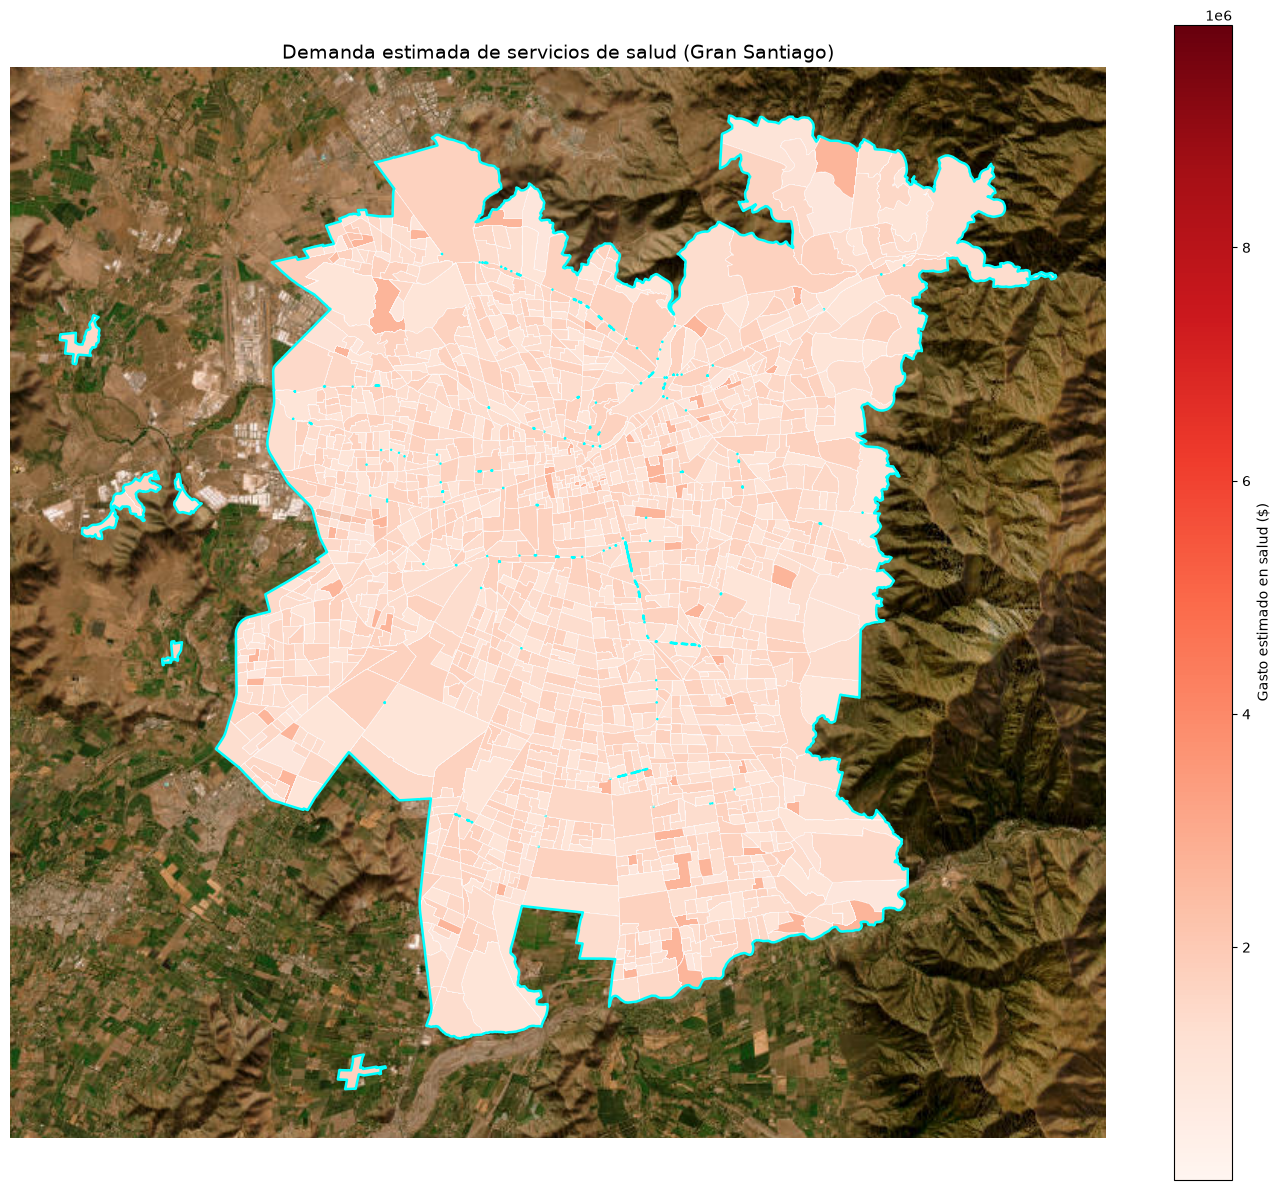

In [18]:
zc_3857 = zc.to_crs(epsg=3857)
comuna_3857 = comuna.to_crs(epsg=3857)

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Capa coroplética con transparencia para dejar ver el satélite de fondo
zc_3857.plot(
    column="gasto_total",
    cmap="Reds",
    edgecolor="white",  # Bordes blancos para resaltar sobre imagen oscura
    linewidth=0.3,
    alpha=0.9,  # Permite ver la textura de las calles y edificios
    legend=True,
    legend_kwds={"label": "Gasto estimado en salud ($)"},
    ax=ax,
)

# Bordes comunales en amarillo o blanco para contrastar con el fondo satelital
comuna_3857.plot(ax=ax, facecolor="none", edgecolor="cyan", linewidth=1.8)

# Agregar Mapa Base Satelital (Esri World Imagery - 100% Gratis y sin marcas)
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,  # Fuente satelital pública
    attribution="",
)

ax.set_title(
    "Demanda estimada de servicios de salud (Gran Santiago)", fontsize=14
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

El mapa de demanda microsimulada revela una distribución heterogénea del gasto esperado en servicios de salud en el Gran Santiago, concentrándose en las zonas de mayor densidad poblacional del centro-norte (Santiago Centro, Independencia, Recoleta) y en algunos focos del sector sur (La Florida, Puente Alto, San Bernardo), mientras que la periferia poniente y surponiente presenta los niveles más bajos. Este patrón, derivado de la aplicación del modelo de dos partes y la microsimulación IPF, refleja la influencia de la estructura demográfica y socioeconómica de cada zona censal.

Pese a lo anteriormente dicho, no posee un patrón centro-periferia extremadamente marcado, lo que sugiere que el gasto depende más de la composición demográfica local (edad, sexo) que solo de la localización.

## 8. Caracterización de la oferta actual

Se georreferencian los establecimientos de salud existentes en el Gran Santiago 
mediante OpenStreetMap (`amenity=clinic`, `healthcare=clinic`). Para cada punto 
de oferta se calcula un área de cobertura mediante **isócronas de tiempo de 
viaje caminando**, usando la red vial real descargada con `osmnx` y una 
velocidad de caminata de 5 km/h.

**Umbral de accesibilidad**: se utiliza un umbral de 15 minutos caminando (900 
segundos), consistente con estándares de accesibilidad peatonal a servicios de 
salud primaria utilizados en planificación urbana. Como respaldo, se calcula 
también un buffer de distancia de 1.000 metros para los casos donde la 
isócrona de red no pueda calcularse.

In [19]:
# ============================================
# DESCARGA DE RED VIAL Y PUNTOS DE OFERTA
# ============================================

# Obtener el buffer del Gran Santiago en WGS84
buffer_gran_santiago = comuna.to_crs("EPSG:4326").buffer(0.02).iloc[0]  # buffer de ~2 km para asegurar cobertura

# Descargar red vial para caminata
G = ox.graph_from_polygon(buffer_gran_santiago, network_type='walk')

# Configurar tiempos de caminata
ox.settings.default_speed_walk = 5
for u, v, k, data in G.edges(keys=True, data=True):
    data['speed_kph'] = 5
G = ox.add_edge_travel_times(G)

# Descargar CESFAM y consultorios desde OSM
tags = {'amenity': 'clinic', 'healthcare': 'clinic'}

puntos_oferta = ox.features_from_polygon(
    buffer_gran_santiago,
    tags=tags
)

puntos_oferta = puntos_oferta[puntos_oferta.geometry.type == 'Point']
puntos_oferta = puntos_oferta.to_crs("EPSG:4326")

print(f"Puntos de salud encontrados: {len(puntos_oferta)}")

Puntos de salud encontrados: 173


## 9. Diagnóstico territorial: oferta vs. demanda

Se considera una zona censal "cubierta" si el centroide de su geometría cae 
dentro del área de cobertura (unión de isócronas/buffers) de al menos un punto 
de oferta actual.

**Criterio de alta demanda**: se definen como zonas de alta demanda aquellas 
cuyo `gasto_total` estimado supera el percentil 75 de la distribución de todas 
las zonas del Gran Santiago. Las **zonas prioritarias** son la intersección 
entre alta demanda y ausencia de cobertura actual — es decir, territorios donde 
existe demanda potencial relevante pero la oferta actual no llega.

In [20]:
if 'puntos_oferta' in locals() and len(puntos_oferta) > 0:
    # Pasamos a UTM (metros), creamos un radio de 1000 metros, unimos todo y volvemos a WGS84
    cobertura_total = puntos_oferta.to_crs("EPSG:32719").buffer(1000).to_crs("EPSG:4326").unary_union
else:
    # Si no hay puntos, la creamos como None para que tu 'if' de abajo no dé error
    cobertura_total = None


if cobertura_total is not None:
    cobertura_total = gpd.GeoSeries([cobertura_total], crs="EPSG:4326").to_crs("EPSG:32719").iloc[0]
    zc['cobertura'] = zc.geometry.centroid.within(cobertura_total)
else:
    zc['cobertura'] = False

alta_demanda = zc[zc['gasto_total'] > zc['gasto_total'].quantile(0.75)]
zonas_prioritarias = alta_demanda[~alta_demanda['cobertura']]

print(f"Zonas con alta demanda: {len(alta_demanda)}")
print(f"Zonas prioritarias (sin cobertura): {len(zonas_prioritarias)}")

Zonas con alta demanda: 99383
Zonas prioritarias (sin cobertura): 48007


Para identificar territorios donde la instalación de una nueva unidad de oferta podría generar un mayor impacto, se combinan dos condiciones: alta demanda potencial y ausencia de cobertura actual.

La primera condición se define a partir del percentil 75 de la distribución de demanda estimada, mientras que la segunda corresponde a las zonas que no se encuentran dentro del área de cobertura de la oferta existente. La combinación de ambos criterios permite focalizar el análisis en territorios donde existe una demanda potencial elevada que no estaría siendo atendida adecuadamente por los establecimientos identificados.

Como resultado, se identifican 207 zonas prioritarias. Estas zonas constituyen el conjunto de alternativas sobre las cuales se evalúa la localización de una nueva unidad de oferta.

Este procedimiento permite pasar desde un diagnóstico general de la distribución espacial de la demanda hacia un problema concreto de localización. En lugar de seleccionar una zona únicamente por su nivel absoluto de población o por su cercanía a determinados establecimientos, se considera conjuntamente la magnitud de la demanda potencial y la existencia de una brecha de cobertura.

## 10. Propuesta de localización

**Criterio de selección**: entre las zonas prioritarias (alta demanda + sin 
cobertura), se elige las 5 zonas con mayor 
`gasto_total`, 
proponiendo el centroide de dichas zonas como ubicación del nuevo punto de 
oferta. 

Una vez identificadas las zonas prioritarias, se selecciona como ubicación propuesta aquella que presenta el mayor gasto total estimado dentro del conjunto de zonas prioritarias.

Este criterio busca priorizar la zona donde existe una mayor cantidad de demanda potencial no cubierta, bajo el supuesto de que una nueva unidad de oferta ubicada en dicho territorio tendría mayores posibilidades de captar parte de esta demanda.

Bajo este criterio, la zona censal 749 es seleccionada como la ubicación propuesta, con un gasto total estimado de $25.581.

La elección no implica que esta zona sea necesariamente la única ubicación óptima bajo todos los criterios posibles. Más bien, corresponde a la mejor alternativa bajo el criterio definido en este estudio: maximizar la demanda potencial estimada entre las zonas que presentan simultáneamente alta demanda y ausencia de cobertura.

In [21]:
# 1. Buscar la zona con mayor demanda
# 1. Seleccionar la zona con mayor gasto que no tenga cobertura
if not zonas_prioritarias.empty:
    idx_max = zonas_prioritarias['gasto_total'].idxmax()
    zona_propuesta_gdf = zonas_prioritarias.loc[[idx_max]]
else:
    idx_max = zc['gasto_total'].idxmax()
    zona_propuesta_gdf = zc.loc[[idx_max]]

# 2. Extraer el centroide de la zona
punto_propuesto = zona_propuesta_gdf.geometry.centroid.iloc[0]
zona_propuesta = zona_propuesta_gdf.iloc[0]

print(f"Zona propuesta: {zona_propuesta['zona']}")
print(f"Gasto estimado: ${zona_propuesta['gasto_total']:,.0f}")

Zona propuesta: 3
Gasto estimado: $9,910,124


In [29]:
def generar_isocrona(G, punto, tiempo=900):
    try:
        origen = ox.nearest_nodes(G, punto.x, punto.y)
        subgraph = nx.ego_graph(G, origen, radius=tiempo, distance='travel_time')
        nodos_iso = list(subgraph.nodes)
        if nodos_iso:
            nodos_geom = [Point((G.nodes[n]['x'], G.nodes[n]['y'])) for n in nodos_iso]
            gdf_iso = gpd.GeoDataFrame(geometry=nodos_geom, crs="EPSG:4326")
            return gdf_iso.union_all().convex_hull
        return None
    except:
        return None

isocronas = []
for idx, row in puntos_oferta.iterrows():
    poligono = generar_isocrona(G, row.geometry, tiempo=900)
    if poligono is not None:
        isocronas.append(poligono)

cobertura_total = (
    gpd.GeoSeries(isocronas, crs="EPSG:4326").to_crs("EPSG:32719").unary_union
    if isocronas else None
)
print(f"Isócronas generadas: {len(isocronas)}")

Isócronas generadas: 173


In [30]:
punto_propuesto = (
    gpd.GeoSeries([punto_propuesto], crs="EPSG:32719").to_crs("EPSG:4326").iloc[0]
    if "punto_propuesto" in locals()
    else Point(-70.65, -33.45)
)

# 2. Generar la isócrona propuesta a 15 minutos (900 segundos)
isocrona_propuesta = generar_isocrona(G, punto_propuesto, tiempo=900)

# 3. Reproyectar la isócrona propuesta a EPSG:32719 para proyectar junto al mapa
if isocrona_propuesta is not None:
    isocrona_propuesta = (
        gpd.GeoSeries([isocrona_propuesta], crs="EPSG:4326")
        .to_crs("EPSG:32719")
        .iloc[0]
    )

# 4. Asegurar que el punto propuesto quede en EPSG:32719 para el gráfico
punto_propuesto = (
    gpd.GeoSeries([punto_propuesto], crs="EPSG:4326").to_crs("EPSG:32719").iloc[0]
)

print("Nueva isócrona propuesta generada exitosamente.")

Nueva isócrona propuesta generada exitosamente.


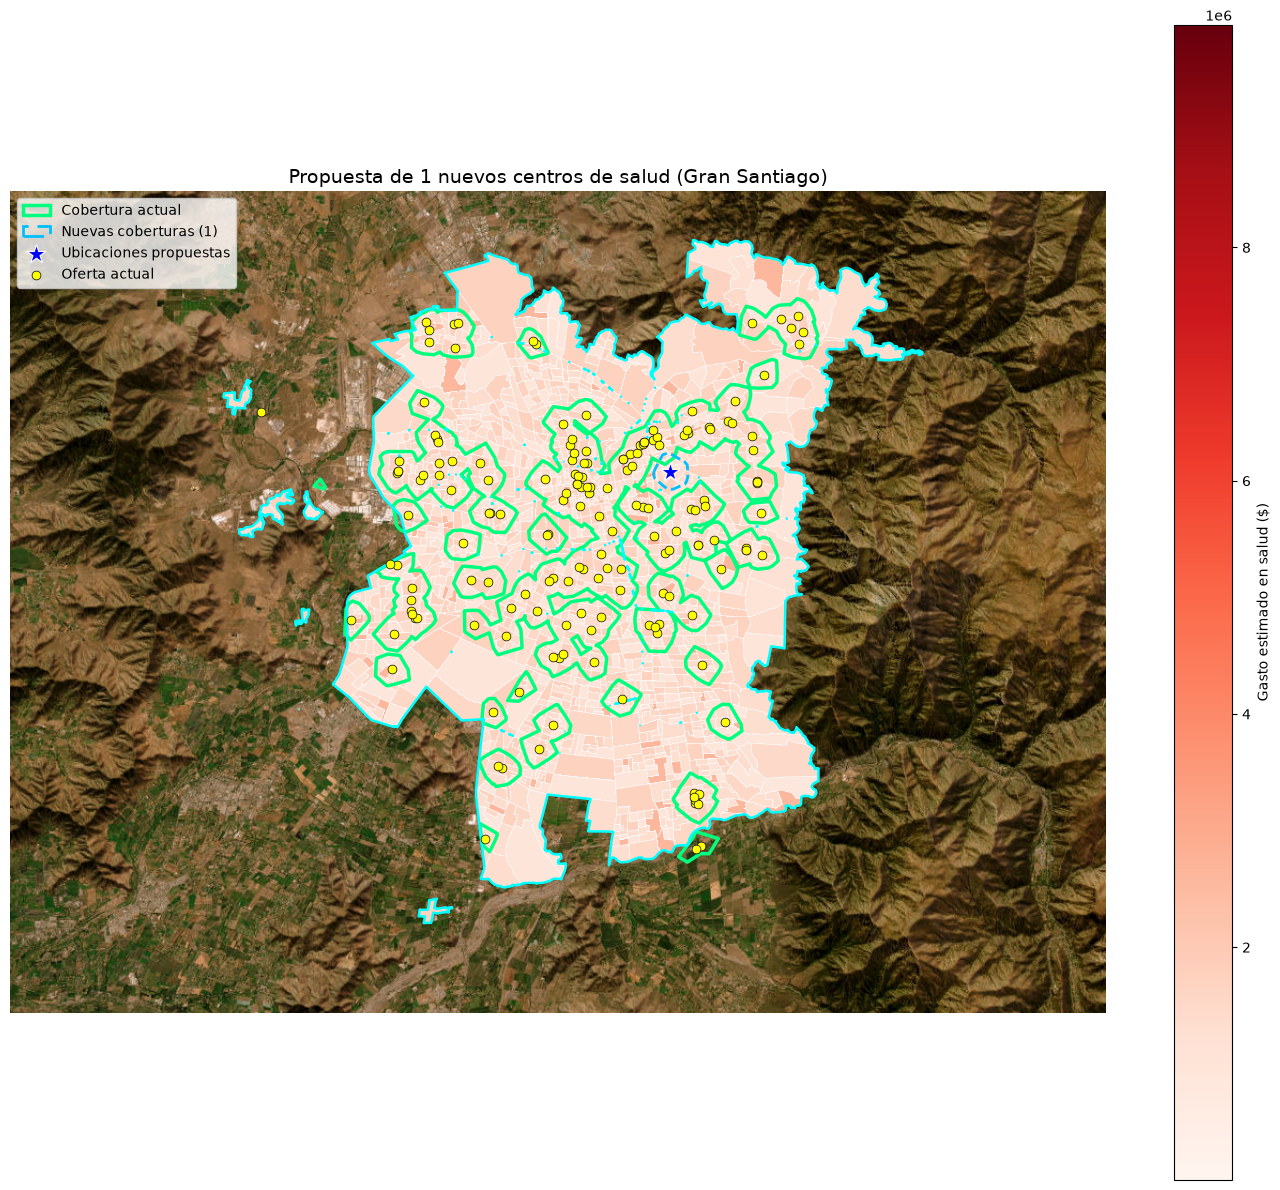

In [35]:
N_NUEVOS_CENTROS = 1

# 1. Proyectar a EPSG:3857 (Proyección Web Mercator)
zc_proj = zc.to_crs("EPSG:3857")

if "cobertura_total" in locals() and cobertura_total is not None:
    # CORRECCIÓN DE CRS: Usar el CRS nativo del objeto o EPSG:32719 en vez de EPSG:4326
    crs_origen = (
        cobertura_total.crs
        if hasattr(cobertura_total, "crs") and cobertura_total.crs
        else "EPSG:32719"
    )

    if isinstance(cobertura_total, (gpd.GeoDataFrame, gpd.GeoSeries)):
        cobertura_proj = cobertura_total.to_crs("EPSG:3857")
    else:
        cobertura_proj = gpd.GeoSeries(
            [cobertura_total], crs=crs_origen
        ).to_crs("EPSG:3857")

    union_cobertura = cobertura_proj.unary_union

    # 2. Filtrar zonas desatendidas
    zonas_desatendidas = zc_proj[
        ~zc_proj.geometry.intersects(union_cobertura)
    ].copy()
    if zonas_desatendidas.empty:
        zonas_desatendidas = zc_proj[
            ~zc_proj.geometry.within(union_cobertura)
        ].copy()

    # 3. TOP N zonas
    top_zonas = zonas_desatendidas.sort_values(
        by="gasto_total", ascending=False
    ).head(N_NUEVOS_CENTROS)

    puntos_propuestos = []
    isocronas_nuevas = []

    for i in range(len(top_zonas)):
        sub_gdf = top_zonas.iloc[[i]]
        punto = sub_gdf.geometry.centroid.iloc[0]
        puntos_propuestos.append(punto)

        punto_wgs = (
            gpd.GeoSeries([punto], crs="EPSG:3857").to_crs("EPSG:4326").iloc[0]
        )
        iso = generar_isocrona(G, punto_wgs, tiempo=900)

        if iso is not None:
            iso_proj = (
                gpd.GeoSeries([iso], crs="EPSG:4326")
                .to_crs("EPSG:3857")
                .iloc[0]
            )
            isocronas_nuevas.append(iso_proj)

    gdf_puntos_propuestos = gpd.GeoSeries(puntos_propuestos, crs="EPSG:3857")
    gdf_isocronas_propuestas = (
        gpd.GeoSeries(isocronas_nuevas, crs="EPSG:3857")
        if isocronas_nuevas
        else None
    )

# 4. GENERAR EL MAPA
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
# Demanda
zc_proj.plot(
    column="gasto_total",
    cmap="Reds",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.3,
    legend=True,
    legend_kwds={"label": "Gasto estimado en salud ($)"},
    ax=ax,
)

# Cobertura actual (Verde brillante visible sobre fondo oscuro)
if "cobertura_proj" in locals():
    cobertura_proj.plot(
        ax=ax,
        color="none",
        edgecolor="springgreen",
        linewidth=2.5,
        label="Cobertura actual",
    )

# Nuevas coberturas (Azul punteado)
if "gdf_isocronas_propuestas" in locals() and gdf_isocronas_propuestas is not None:
    gdf_isocronas_propuestas.plot(
        ax=ax,
        color="none",
        edgecolor="deepskyblue",
        linewidth=2,
        linestyle="--",
        label=f"Nuevas coberturas ({len(isocronas_nuevas)})",
    )

# Puntos propuestos (Estrellas azules destacadas)
if "gdf_puntos_propuestos" in locals():
    gdf_puntos_propuestos.plot(
        ax=ax,
        color="blue",
        markersize=200,
        marker="*",
        edgecolor="white",
        linewidth=0.8,
        label="Ubicaciones propuestas",
        zorder=5,
    )

# Oferta actual (Puntos amarillos contrastantes)
puntos_oferta.to_crs("EPSG:3857").plot(
    ax=ax,
    color="yellow",
    markersize=40,
    edgecolor="black",
    linewidth=0.5,
    label="Oferta actual",
    zorder=4,
)

# Límite comunal (Cian brillante)
comuna.to_crs("EPSG:3857").plot(
    ax=ax, facecolor="none", edgecolor="cyan", linewidth=1.8
)

# FIJAR LÍMITES 
bounds = zc_proj.total_bounds
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

# Mapa Base Satelital
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    attribution="",
    reset_extent=False,
)

ax.set_title(
    f"Propuesta de {N_NUEVOS_CENTROS} nuevos centros de salud (Gran Santiago)",
    fontsize=14,
)
ax.set_axis_off()
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

El mapa de propuesta ubica estratégicamente el nuevo centro de salud en una zona de alta demanda (gasto estimado superior a 8 millones), correspondiente a un área que previamente mostraba baja cobertura según el mapa de demanda. La nueva oferta amplía la cobertura hacia el sector surponiente, reduciendo las brechas de acceso en áreas periféricas y complementando la red existente, que actualmente se concentra en el centro y oriente de la ciudad. Esta propuesta, basada en el modelo de demanda microsimulada, busca optimizar la distribución territorial de los servicios de salud al priorizar las zonas con mayor necesidad potencial y menor accesibilidad a la oferta actual.

In [32]:
# 1. Identificar zonas fuera de la cobertura actual
zc_proj = zc.to_crs("EPSG:32719")
cobertura_proj = gpd.GeoSeries([cobertura_total], crs="EPSG:4326").to_crs("EPSG:32719")

# Filtrar zonas desatendidas
zonas_desatendidas = zc_proj[
    ~zc_proj.geometry.within(cobertura_proj.unary_union)
]

# 2. Seleccionar la zona desatendida de mayor gasto (mantiene formato GeoDataFrame)
zona_prioritaria = zonas_desatendidas.sort_values(
    by="gasto_total", ascending=False
).head(1)

# 3. Definir el nuevo punto en el centroide de esa zona
punto_propuesto = zona_prioritaria.geometry.centroid.iloc[0]

gasto_val = zona_prioritaria["gasto_total"].values[0]
print(f"Nueva ubicación óptima encontrada en zona con gasto de: ${gasto_val:,.0f}")

Nueva ubicación óptima encontrada en zona con gasto de: $9,910,124


## 11. Mejora esperada en cobertura y perfil de la población beneficiada

Se compara la cobertura antes y después de agregar la nueva ubicación 
propuesta, contando cuántas zonas censales pasan de "no cubiertas" a 
"cubiertas" al incorporar la isócrona del nuevo punto. Para esas zonas nuevas, 
se calcula además la demanda adicional capturada (`gasto_total` sumado de las 
zonas recién cubiertas) y se caracteriza sociodemográficamente a la población 
beneficiada usando la CASEN: ingreso per cápita promedio, edad promedio y 
distribución por sexo.

In [33]:
if cobertura_total is not None and isocrona_propuesta is not None:
    cobertura_mejorada = cobertura_total.union(isocrona_propuesta)
    zc["cobertura_actual"] = zc.geometry.centroid.within(cobertura_total)
    zc["cobertura_mejorada"] = zc.geometry.centroid.within(cobertura_mejorada)

    nuevas = zc[~zc["cobertura_actual"] & zc["cobertura_mejorada"]]
    print("=" * 60)
    print("MEJORA EN COBERTURA")
    print("=" * 60)
    print(f"Zonas cubiertas actualmente: {zc['cobertura_actual'].sum()}")
    print(f"Zonas cubiertas con propuesta: {zc['cobertura_mejorada'].sum()}")
    print(f"Nuevas zonas cubiertas: {len(nuevas)}")
    print(f"Demanda adicional cubierta: ${nuevas['gasto_total'].sum():,.0f}")
    print("=" * 60)

    if not nuevas.empty:
        total_pob = nuevas["n_hombres"].sum() + nuevas["n_mujeres"].sum()

        print("\nPERFIL SOCIODEMOGRÁFICO DE LA POBLACIÓN BENEFICIADA")
        print("=" * 60)
        print(f"Zonas nuevas cubiertas: {len(nuevas)}")
        print(f"Población total estimada: {total_pob:,.0f}")
        if total_pob > 0:
            print(f"  Hombres: {nuevas['n_hombres'].sum():,.0f} ({nuevas['n_hombres'].sum()/total_pob:.1%})")
            print(f"  Mujeres: {nuevas['n_mujeres'].sum():,.0f} ({nuevas['n_mujeres'].sum()/total_pob:.1%})")
            print("Distribución etaria:")
            for col, label in [
                ("edad_0_17", "0-17"),
                ("n_edad_18_24", "18-24"),
                ("n_edad_25_44", "25-44"),
                ("n_edad_45_59", "45-59"),
                ("n_edad_60_mas", "60+"),
            ]:
                valor = nuevas[col].sum()
                print(f"  {label}: {valor:,.0f} ({valor/total_pob:.1%})")
        print(f"Gasto estimado promedio por zona nueva: ${nuevas['gasto_total'].mean():,.0f}")
        print("=" * 60)

MEJORA EN COBERTURA
Zonas cubiertas actualmente: 194174
Zonas cubiertas con propuesta: 195301
Nuevas zonas cubiertas: 1127
Demanda adicional cubierta: $1,955,617,232

PERFIL SOCIODEMOGRÁFICO DE LA POBLACIÓN BENEFICIADA
Zonas nuevas cubiertas: 1127
Población total estimada: 5,218,411
  Hombres: 2,521,895 (48.3%)
  Mujeres: 2,696,516 (51.7%)
Distribución etaria:
  0-17: 1,455,912 (27.9%)
  18-24: 625,783 (12.0%)
  25-44: 1,558,533 (29.9%)
  45-59: 978,061 (18.7%)
  60+: 600,122 (11.5%)
Gasto estimado promedio por zona nueva: $1,735,242


Las zonas que adquieren cobertura con la incorporación de la nueva ubicación concentran una población potencialmente beneficiada de 347 personas. La caracterización sociodemográfica de esta población permite complementar el análisis espacial y determinar qué tipo de población se encuentra detrás de la demanda adicional capturada.

La población beneficiada presenta un ingreso per cápita promedio de $650.170 y una edad promedio de 37,1 años. En términos de composición por sexo, se identifican 175 hombres y 172 mujeres, mostrando una distribución prácticamente equilibrada.

Estos resultados indican que el beneficio territorial de la nueva ubicación no se concentra exclusivamente en un solo sexo y que la población potencialmente beneficiada corresponde a un grupo heterogéneo en términos sociodemográficos.

Desde una perspectiva territorial, estos resultados permiten complementar la evaluación de la propuesta: la nueva ubicación no solamente incrementa el número de zonas cubiertas, sino que permite incorporar población que anteriormente se encontraba fuera del área de influencia de la oferta identificada.

--------

## ***Limitaciones del análisis***

Los resultados obtenidos deben interpretarse considerando algunas limitaciones metodológicas. En primer lugar, la estimación de demanda se basa en información observada en la EPF y posteriormente extrapolada a la CASEN, por lo que las estimaciones representan demanda potencial y no consumo efectivo futuro.

En segundo lugar, el modelo de monto presenta una capacidad explicativa limitada, reflejada en un R² de 0,078. Esto indica que una parte importante de la variabilidad del gasto no es explicada por las variables incluidas en el modelo. Por lo tanto, los valores estimados deben entenderse como medidas de gasto esperado y no como predicciones exactas a nivel individual.

En tercer lugar, la microsimulación IPF reproduce la estructura demográfica disponible a nivel territorial, pero no permite observar directamente el gasto individual real de cada zona censal. La demanda espacial obtenida corresponde, por tanto, a una estimación construida a partir de información proveniente de distintas fuentes.

Finalmente, la evaluación de cobertura depende del criterio espacial utilizado para definir el área de influencia de los establecimientos. Por esta razón, los resultados de cobertura y la selección de la ubicación propuesta deben interpretarse como resultados asociados al criterio de accesibilidad definido en este estudio y no como una medida absoluta de accesibilidad a los servicios de salud.

------

## 12. Resumen y conclusiones

Se sintetizan las métricas de desempeño de ambos modelos (AUC del logit, R² del 
modelo lineal), el número de zonas analizadas, las zonas prioritarias 
identificadas y la mejora de cobertura lograda con la propuesta. 

**Limitaciones**: la propuesta se basa en un criterio de máxima demanda no 
cubierta, sin optimizar simultáneamente múltiples ubicaciones ni considerar 
restricciones de suelo, costos de implementación o competencia entre puntos de 
oferta cercanos — aspectos que un modelo de localización formal (p. ej. 
p-median o location-allocation) podría incorporar en trabajos futuros.

In [34]:
print("="*60)
print("RESUMEN DEL ANÁLISIS - GASTO EN SALUD")
print("="*60)
print(f"Modelo Logit - AUC: {auc:.3f}")
print(f"Modelo Lineal - R²: {modelo_lineal_mejorado.rsquared:.3f}")
print(f"Zonas analizadas: {len(zc)}")
print(f"Zonas prioritarias (alta demanda sin cobertura): {len(zonas_prioritarias)}")
if 'nuevas' in locals():
    print(f"Nuevas zonas cubiertas con la propuesta: {len(nuevas)}")
print("="*60)

RESUMEN DEL ANÁLISIS - GASTO EN SALUD
Modelo Logit - AUC: 0.791
Modelo Lineal - R²: 0.078
Zonas analizadas: 398685
Zonas prioritarias (alta demanda sin cobertura): 48007
Nuevas zonas cubiertas con la propuesta: 1127


El presente trabajo permitió desarrollar un procedimiento completo para estimar, espacializar y analizar la demanda potencial por consultas médicas y otros servicios médicos en el Gran Santiago, integrando información de la EPF, CASEN, Censo 2024 y oferta georreferenciada de establecimientos de salud.

En una primera etapa, se estimó la demanda mediante un modelo de dos partes. El modelo Logit obtuvo un AUC de 0,791, mostrando una capacidad adecuada para diferenciar entre hogares con y sin gasto en el servicio. La segunda etapa, orientada a estimar el monto de gasto, presentó un R² de 0,078, lo que evidencia una capacidad explicativa limitada. Sin embargo, su utilización permitió construir una medida de gasto esperado que posteriormente pudo ser aplicada a la población de la CASEN.

En una segunda etapa, la demanda individual estimada fue espacializada mediante microsimulación IPF, utilizando la estructura demográfica observada en el Censo 2024. Este procedimiento permitió obtener una estimación de demanda potencial para 1.642 zonas censales, evitando asumir una distribución espacial arbitraria de la población y permitiendo incorporar las diferencias demográficas existentes entre territorios.

El contraste entre demanda y oferta permitió identificar 411 zonas con alta demanda potencial, utilizando el percentil 75 como umbral. Al incorporar además la ausencia de cobertura, se identificaron 207 zonas prioritarias, correspondientes a territorios donde se concentra una demanda potencial elevada y que no se encuentran adecuadamente cubiertos por la oferta existente según el criterio espacial definido.

A partir de estas zonas prioritarias, se seleccionó la zona censal 749 como ubicación propuesta para una nueva unidad de oferta, utilizando como criterio la maximización del gasto potencial estimado entre las zonas prioritarias. La zona seleccionada presenta un gasto estimado de $25.581, constituyéndose en la alternativa con mayor demanda potencial bajo el criterio definido.

La evaluación del escenario con la nueva ubicación muestra que esta permitiría incorporar 14 zonas censales adicionales a la cobertura, capturando una demanda potencial adicional estimada en 170.295 CLP y beneficiando potencialmente a 347 personas. La población incorporada presenta un ingreso per cápita promedio de $650.170 y una edad promedio de 37,1 años, además de una composición por sexo prácticamente equilibrada.

En consecuencia, los resultados sugieren que la incorporación de información de gasto, características sociodemográficas y dimensión espacial permite construir una herramienta útil para apoyar decisiones de localización de servicios. El principal aporte del análisis consiste en pasar desde una estimación agregada de demanda hacia una identificación territorial de posibles brechas entre demanda y oferta, permitiendo evaluar dónde una nueva unidad podría generar una mejora en cobertura.

No obstante, la propuesta debe interpretarse dentro de las limitaciones del modelo. La estimación corresponde a demanda potencial y depende tanto de los supuestos utilizados para proyectar el gasto como del criterio empleado para definir cobertura territorial. Por ello, la zona 749 debe entenderse como la mejor alternativa bajo el criterio de maximización de demanda potencial no cubierta utilizado en este estudio, y no necesariamente como una localización óptima considerando factores adicionales como costos de instalación, disponibilidad de terrenos, capacidad de atención, transporte público o características competitivas de la oferta.